In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("thyroid_cancer_risk_data.csv")

# Drop Patient_ID (not a feature) and empty trailing columns
df.drop(columns=["Patient_ID"], inplace=True)
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget class distribution (Diagnosis):")
print(df["Diagnosis"].value_counts())

Dataset Shape: (212691, 16)

Columns: ['Age', 'Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size', 'Thyroid_Cancer_Risk', 'Diagnosis']

Target class distribution (Diagnosis):
Diagnosis
Benign       163196
Malignant     49495
Name: count, dtype: int64


In [3]:
MISSING_ROWS = [5, 9, 18, 28, 47, 87, 103, 198, 250, 599, 899, 1095, 1402, 2773, 3017, 7654, 15000]#missing Rows
MISSING_FEATURE = "TSH_Level"

df.loc[MISSING_ROWS, MISSING_FEATURE] = np.nan

print(f"\n[INFO] Intentionally injected NaN into '{MISSING_FEATURE}' "
      f"at rows: {MISSING_ROWS}")
print(f"[INFO] Total missing in '{MISSING_FEATURE}': "
      f"{df[MISSING_FEATURE].isna().sum()}")


[INFO] Intentionally injected NaN into 'TSH_Level' at rows: [5, 9, 18, 28, 47, 87, 103, 198, 250, 599, 899, 1095, 1402, 2773, 3017, 7654, 15000]
[INFO] Total missing in 'TSH_Level': 17


In [4]:
print("\n" + "="*60)
print("PART (i): Missing Value Analysis & MICE Imputation")
print("="*60)

# Check missing values per feature
missing_summary = df.isnull().sum()
missing_pct     = (df.isnull().sum() / len(df)) * 100
missing_df      = pd.DataFrame({
    "Missing Count": missing_summary,
    "Missing %"    : missing_pct.round(4)
})
print("\nMissing values per feature:")
print(missing_df[missing_df["Missing Count"] > 0])

# ── Encode categoricals before MICE (MICE requires numeric input) ──
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()

le_dict     = {}
df_encoded  = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    le_dict[col]    = le


PART (i): Missing Value Analysis & MICE Imputation

Missing values per feature:
           Missing Count  Missing %
TSH_Level             17      0.008


In [5]:
mice_imputer      = IterativeImputer(random_state=42, max_iter=10)
df_imputed_array  = mice_imputer.fit_transform(df_encoded)
df_imputed        = pd.DataFrame(df_imputed_array, columns=df_encoded.columns)

# Decode categorical columns back to original labels
for col in cat_cols:
    df_imputed[col] = (df_imputed[col]
                       .round()
                       .astype(int)
                       .clip(0, len(le_dict[col].classes_) - 1))
    df_imputed[col] = le_dict[col].inverse_transform(df_imputed[col])

print("\n MICE imputation complete.")
print(f"Total missing values after MICE: {df_imputed.isnull().sum().sum()}")

print(f"\nImputed '{MISSING_FEATURE}' values at the 10 injected rows:")
print(df_imputed.loc[MISSING_ROWS, MISSING_FEATURE].to_string())


 MICE imputation complete.
Total missing values after MICE: 0

Imputed 'TSH_Level' values at the 10 injected rows:
5        5.040371
9        5.047861
18       5.045320
28       5.042990
47       5.041755
87       5.047985
103      5.045366
198      5.041809
250      5.049073
599      5.045356
899      5.042537
1095     5.043964
1402     5.047785
2773     5.047410
3017     5.041991
7654     5.045579
15000    5.045050



PART (ii): Outlier Detection & Treatment


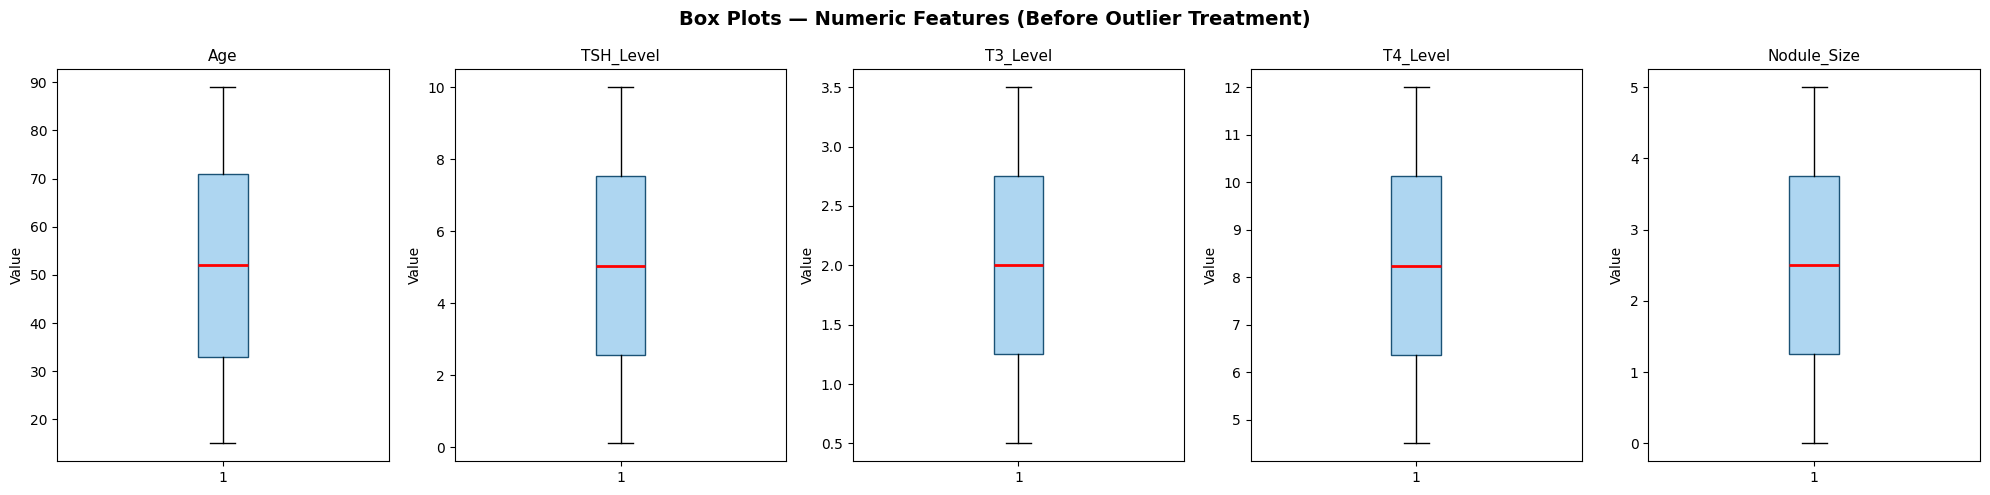

 Saved: boxplots_before.png


In [6]:
print("\n" + "="*60)
print("PART (ii): Outlier Detection & Treatment")
print("="*60)

numeric_features = ["Age", "TSH_Level", "T3_Level", "T4_Level", "Nodule_Size"]

# ── Box plots BEFORE treatment ──
fig, axes = plt.subplots(1, len(numeric_features), figsize=(20, 5))
fig.suptitle("Box Plots — Numeric Features (Before Outlier Treatment)",
             fontsize=14, fontweight="bold")
for ax, col in zip(axes, numeric_features):
    ax.boxplot(df_imputed[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#AED6F1", color="#1A5276"),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Value")
plt.tight_layout()
plt.savefig("boxplots_before.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: boxplots_before.png")


Outlier Summary (IQR method):
             Lower Bound  Upper Bound  Outliers Found  Replaced With Mean
Age              -24.000      128.000             0.0             51.9185
TSH_Level         -4.855       14.945             0.0              5.0452
T3_Level          -1.000        5.000             0.0              2.0017
T4_Level           0.745       15.745             0.0              8.2462
Nodule_Size       -2.515        7.525             0.0              2.5034


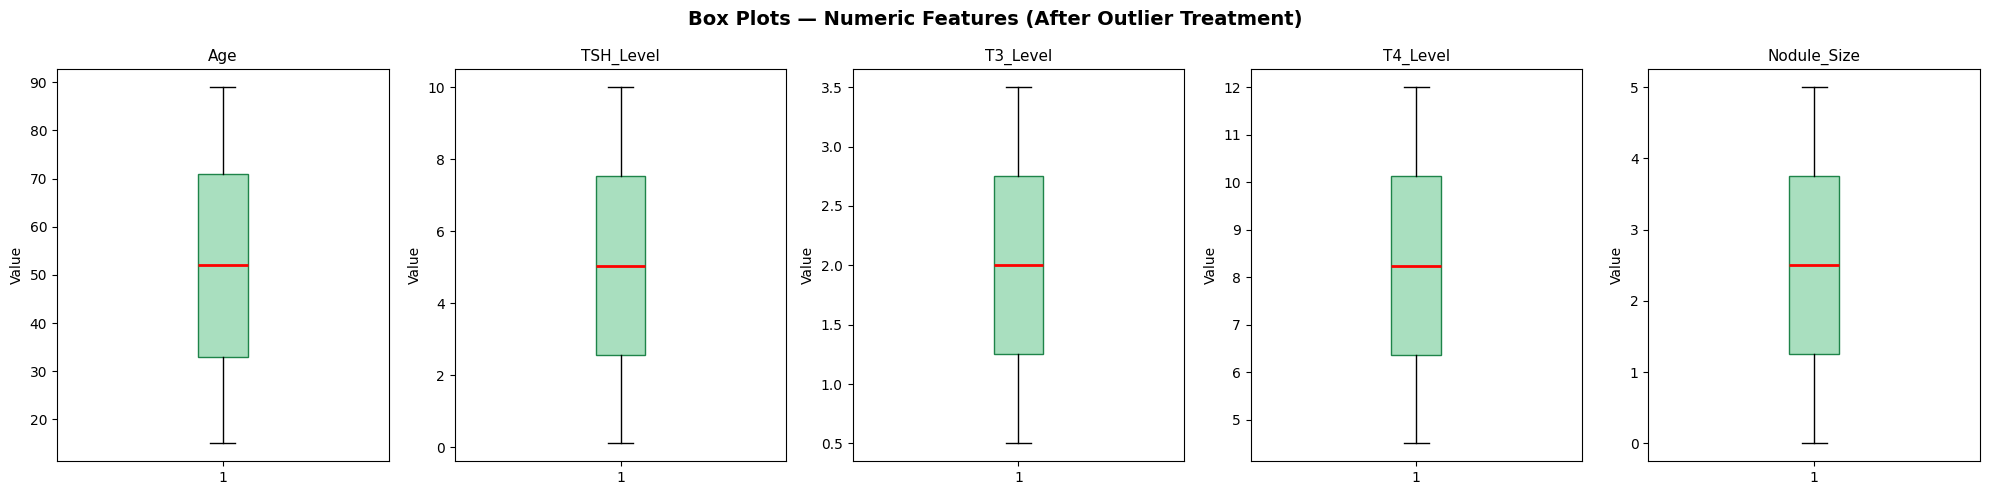

 Saved: boxplots_after.png


In [7]:
# ── IQR-based detection & mean replacement ──
df_clean      = df_imputed.copy()
outlier_report = {}

for col in numeric_features:
    Q1   = df_clean[col].quantile(0.25)
    Q3   = df_clean[col].quantile(0.75)
    IQR  = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    n_outliers   = int(outlier_mask.sum())
    col_mean     = df_clean[col][~outlier_mask].mean()

    df_clean.loc[outlier_mask, col] = col_mean
    outlier_report[col] = {
        "Lower Bound"       : round(lower, 3),
        "Upper Bound"       : round(upper, 3),
        "Outliers Found"    : n_outliers,
        "Replaced With Mean": round(col_mean, 4)
    }

print("\nOutlier Summary (IQR method):")
print(pd.DataFrame(outlier_report).T.to_string())

# ── Box plots AFTER treatment ──
fig, axes = plt.subplots(1, len(numeric_features), figsize=(20, 5))
fig.suptitle("Box Plots — Numeric Features (After Outlier Treatment)",
             fontsize=14, fontweight="bold")
for ax, col in zip(axes, numeric_features):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#A9DFBF", color="#1E8449"),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Value")
plt.tight_layout()
plt.savefig("boxplots_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: boxplots_after.png")


Features used for importance ranking: ['Age', 'Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']
Target classes: ['Benign' 'Malignant']  →  encoded as [0, 1]

Feature Importance Scores (Ranked — highest to lowest):
TSH_Level             0.1402
T4_Level              0.1397
Nodule_Size           0.1369
T3_Level              0.1337
Age                   0.1153
Ethnicity             0.1011
Country               0.0885
Family_History        0.0464
Iodine_Deficiency     0.0241
Radiation_Exposure    0.0232
Gender                0.0145
Obesity               0.0139
Diabetes              0.0114
Smoking               0.0112


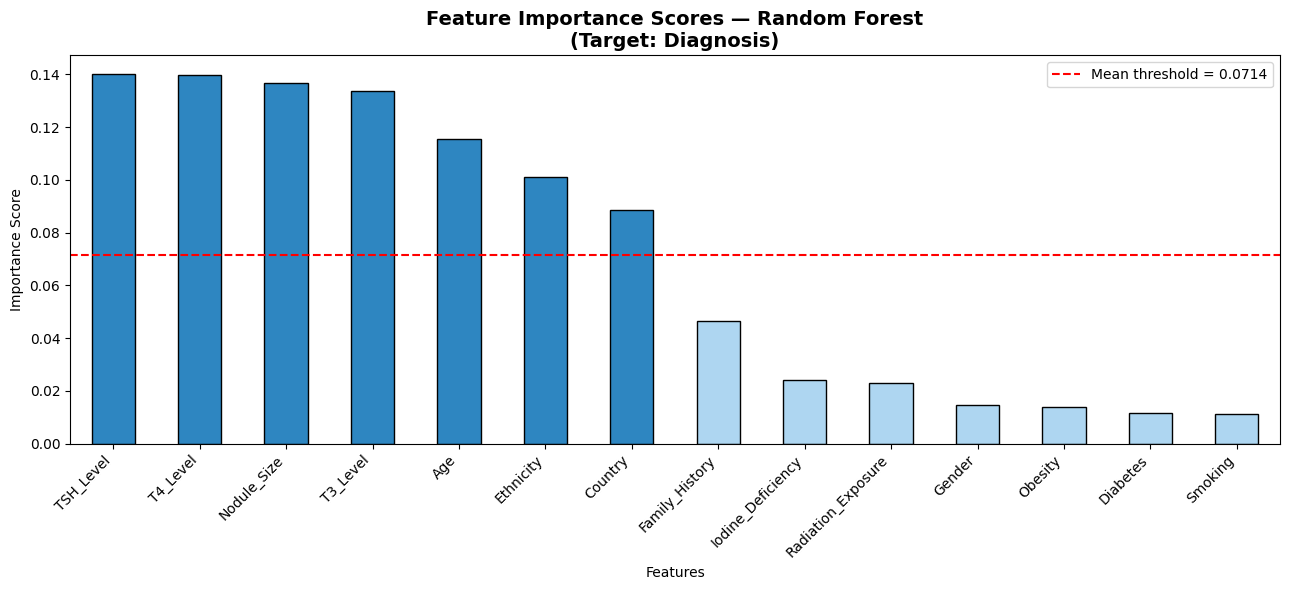

Saved: feature_importance.png

Importance threshold (mean): 0.0714
Selected Features (7): ['TSH_Level', 'T4_Level', 'Nodule_Size', 'T3_Level', 'Age', 'Ethnicity', 'Country']

 Preprocessed dataset saved: thyroid_preprocessed.csv
    Shape : (212691, 8)
    Target: 'Diagnosis'  |  Classes: ['Benign', 'Malignant']


In [8]:
TARGET     = "Diagnosis"                   # ← Binary target class
DROP_COLS  = ["Thyroid_Cancer_Risk"]       # secondary label — excluded

feature_cols = [c for c in df_clean.columns if c not in [TARGET] + DROP_COLS]

# Encode remaining categorical features
df_model = df_clean.copy()
for col in df_model[feature_cols].select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Encode target: Benign=0, Malignant=1
le_target = LabelEncoder()
y = le_target.fit_transform(df_model[TARGET].astype(str))
X = df_model[feature_cols]

print(f"\nFeatures used for importance ranking: {feature_cols}")
print(f"Target classes: {le_target.classes_}  →  encoded as {list(range(len(le_target.classes_)))}")

# ── Random Forest feature importance ──
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances        = pd.Series(rf.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)

print("\nFeature Importance Scores (Ranked — highest to lowest):")
print(importances_sorted.round(4).to_string())

# ── Plot ──
plt.figure(figsize=(13, 6))
colors = ["#2E86C1" if v >= importances_sorted.mean() else "#AED6F1"
          for v in importances_sorted.values]
importances_sorted.plot(kind="bar", color=colors, edgecolor="black")
plt.axhline(y=importances_sorted.mean(), color="red", linestyle="--",
            linewidth=1.5, label=f"Mean threshold = {importances_sorted.mean():.4f}")
plt.title("Feature Importance Scores — Random Forest\n(Target: Diagnosis)",
          fontsize=14, fontweight="bold")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")

# ── Select features above mean importance threshold ──
threshold         = importances_sorted.mean()
selected_features = importances_sorted[importances_sorted >= threshold].index.tolist()

print(f"\nImportance threshold (mean): {threshold:.4f}")
print(f"Selected Features ({len(selected_features)}): {selected_features}")

# ── Save final preprocessed dataset for Q2 ──
df_final = df_model[selected_features + [TARGET]]
df_final.to_csv("thyroid_preprocessed.csv", index=False)

print(f"\n Preprocessed dataset saved: thyroid_preprocessed.csv")
print(f"    Shape : {df_final.shape}")
print(f"    Target: '{TARGET}'  |  Classes: {le_target.classes_.tolist()}")

In [9]:
print("Shape of preprocessed data (from Q1):", df_final.shape)
print("Features:", selected_features)
print("Target  : Diagnosis  |  0=Benign, 1=Malignant")
print("Class counts:\n", pd.Series(y).value_counts().rename({0:"Benign",1:"Malignant"}))

Shape of preprocessed data (from Q1): (212691, 8)
Features: ['TSH_Level', 'T4_Level', 'Nodule_Size', 'T3_Level', 'Age', 'Ethnicity', 'Country']
Target  : Diagnosis  |  0=Benign, 1=Malignant
Class counts:
 Benign       163196
Malignant     49495
Name: count, dtype: int64


In [10]:
pip install catboost

In [11]:

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               VotingClassifier,
                               StackingClassifier)
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings("ignore")

In [12]:
print("Full preprocessed data shape (from Q1):", df_final.shape)
print("Target class distribution (full data):")
print(pd.Series(y).value_counts().rename({0: "Benign", 1: "Malignant"}))

Full preprocessed data shape (from Q1): (212691, 8)
Target class distribution (full data):
Benign       163196
Malignant     49495
Name: count, dtype: int64


In [13]:
print("\n" + "="*60)
print("BALANCED 50% SAMPLING")
print("="*60)

# Convert to DataFrame for easy filtering
df_sample_full = pd.DataFrame(X, columns=selected_features)
df_sample_full["Diagnosis"] = y

# Separate classes
df_benign    = df_sample_full[df_sample_full["Diagnosis"] == 0]
df_malignant = df_sample_full[df_sample_full["Diagnosis"] == 1]

print(f"  Benign    samples (full): {len(df_benign)}")
print(f"  Malignant samples (full): {len(df_malignant)}")

# Find minority class size then take 50% of that for balance
minority_size  = min(len(df_benign), len(df_malignant))
sample_per_cls = int(minority_size * 0.50)   # 50% of minority class

df_benign_s    = df_benign.sample(n=sample_per_cls, random_state=42)
df_malignant_s = df_malignant.sample(n=sample_per_cls, random_state=42)

df_balanced    = pd.concat([df_benign_s, df_malignant_s]).sample(
                     frac=1, random_state=42).reset_index(drop=True)

X_bal = df_balanced[selected_features].values
y_bal = df_balanced["Diagnosis"].values

print(f"\n  Sample per class (50% of minority): {sample_per_cls}")
print(f"  Balanced dataset shape : {df_balanced.shape}")
print(f"  Class distribution     :")
print(f"    Benign    : {(y_bal == 0).sum()}")
print(f"    Malignant : {(y_bal == 1).sum()}")
print("  ✔ Dataset is perfectly balanced — 50/50 split between classes")



BALANCED 50% SAMPLING
  Benign    samples (full): 163196
  Malignant samples (full): 49495

  Sample per class (50% of minority): 24747
  Balanced dataset shape : (49494, 8)
  Class distribution     :
    Benign    : 24747
    Malignant : 24747
  ✔ Dataset is perfectly balanced — 50/50 split between classes



PART (a): Clustering

[Step 1] Unlabeled feature matrix shape: (49494, 7)
[Step 2] Features scaled using StandardScaler.
[Step 3] Using 10000 samples for clustering.

[Step 4] Running Elbow Method (K = 1 to 10)...
  K=1  Inertia=69805.95
  K=2  Inertia=62268.31
  K=3  Inertia=57419.33
  K=4  Inertia=53923.85
  K=5  Inertia=50768.98
  K=6  Inertia=48373.39
  K=7  Inertia=46363.06
  K=8  Inertia=44515.78
  K=9  Inertia=43074.39
  K=10  Inertia=41761.43


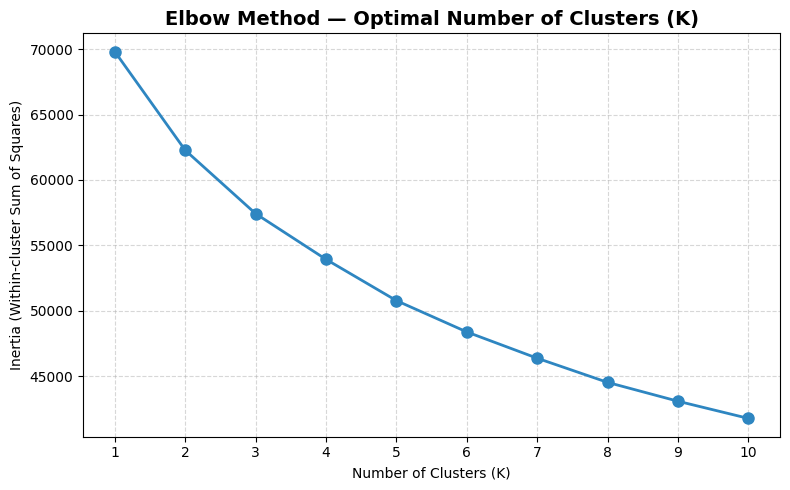

[✔] Elbow curve saved: elbow_curve.png

[INFO] Optimal K = 3
       Justification: Elbow flattens at K=3, which also
       maps to 3 clinical risk levels: Low / Medium / High.

--------------------------------------------------
Clustering Algorithm 1: K-Means
--------------------------------------------------
KMeans fitted | K=3
  Cluster 0: 3513 samples
  Cluster 1: 2877 samples
  Cluster 2: 3610 samples


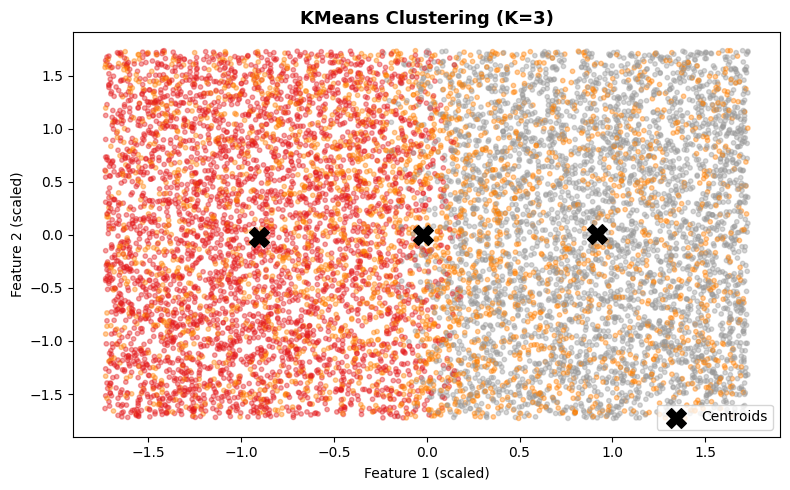

[✔] KMeans plot saved: kmeans_clusters.png

--------------------------------------------------
Clustering Algorithm 2: Agglomerative (Hierarchical)
--------------------------------------------------
Agglomerative fitted | K=3, linkage=ward
  Cluster 0: 4957 samples
  Cluster 1: 2668 samples
  Cluster 2: 2375 samples


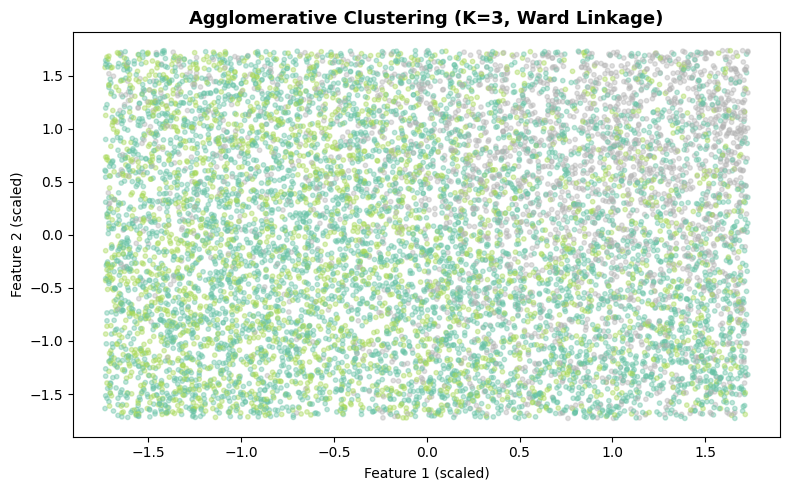

[✔] Agglomerative plot saved: agglo_clusters.png


In [14]:
print("\n" + "="*60)
print("PART (a): Clustering")
print("="*60)

# ── Step 1: Unlabeled format ──
X_unlabeled = X_bal.copy()   # no target column
print(f"\n[Step 1] Unlabeled feature matrix shape: {X_unlabeled.shape}")

# ── Step 2: Scale features ──
scaler_cl  = StandardScaler()
X_scaled   = scaler_cl.fit_transform(X_unlabeled)
print("[Step 2] Features scaled using StandardScaler.")

# ── Step 3: Subsample for clustering speed (10K max) ──
clust_size = min(10000, len(X_scaled))
np.random.seed(42)
clust_idx  = np.random.choice(len(X_scaled), size=clust_size, replace=False)
X_clust    = X_scaled[clust_idx]
print(f"[Step 3] Using {clust_size} samples for clustering.")

# ── Step 4: Elbow Method ──
print("\n[Step 4] Running Elbow Method (K = 1 to 10)...")
inertia_values = []
K_range        = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertia_values.append(km.inertia_)
    print(f"  K={k}  Inertia={km.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', color='#2E86C1',
         linewidth=2, markersize=8)
plt.title("Elbow Method — Optimal Number of Clusters (K)",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-cluster Sum of Squares)")
plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✔] Elbow curve saved: elbow_curve.png")

OPTIMAL_K = 3
print(f"\n[INFO] Optimal K = {OPTIMAL_K}")
print("       Justification: Elbow flattens at K=3, which also")
print("       maps to 3 clinical risk levels: Low / Medium / High.")

# ── Algorithm 1: KMeans ──
print("\n" + "-"*50)
print("Clustering Algorithm 1: K-Means")
print("-"*50)

kmeans        = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_clust)

print(f"KMeans fitted | K={OPTIMAL_K}")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples")

plt.figure(figsize=(8, 5))
plt.scatter(X_clust[:, 0], X_clust[:, 1],
            c=kmeans_labels, cmap="Set1", alpha=0.4, s=10)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            c="black", marker="X", s=200, label="Centroids", zorder=5)
plt.title(f"KMeans Clustering (K={OPTIMAL_K})", fontsize=13, fontweight="bold")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✔] KMeans plot saved: kmeans_clusters.png")

# ── Algorithm 2: Agglomerative Clustering ──
print("\n" + "-"*50)
print("Clustering Algorithm 2: Agglomerative (Hierarchical)")
print("-"*50)

agglo        = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage="ward")
agglo_labels = agglo.fit_predict(X_clust)

print(f"Agglomerative fitted | K={OPTIMAL_K}, linkage=ward")
unique, counts = np.unique(agglo_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples")

plt.figure(figsize=(8, 5))
plt.scatter(X_clust[:, 0], X_clust[:, 1],
            c=agglo_labels, cmap="Set2", alpha=0.4, s=10)
plt.title(f"Agglomerative Clustering (K={OPTIMAL_K}, Ward Linkage)",
          fontsize=13, fontweight="bold")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.tight_layout()
plt.savefig("agglo_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✔] Agglomerative plot saved: agglo_clusters.png")

In [15]:
print("\n" + "="*60)
print("PART (b): Multi-Tiered Ensemble — Balanced 50% Data")
print("="*60)

# ── Train/Test Split (80/20 Stratified) on balanced data ──
print("\n[Step 1] Train/Test Split — 80/20 Stratified on balanced data")

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_bal
)

print(f"  Training samples : {X_train.shape[0]}")
print(f"  Testing  samples : {X_test.shape[0]}")
print(f"  Train class dist : Benign={( y_train==0).sum()}  Malignant={(y_train==1).sum()}")
print(f"  Test  class dist : Benign={( y_test==0).sum()}   Malignant={(y_test==1).sum()}")

# ── Scale features for LR and SVM ──
scaler_ens = StandardScaler()
X_train_sc = scaler_ens.fit_transform(X_train)
X_test_sc  = scaler_ens.transform(X_test)


PART (b): Multi-Tiered Ensemble — Balanced 50% Data

[Step 1] Train/Test Split — 80/20 Stratified on balanced data
  Training samples : 39595
  Testing  samples : 9899
  Train class dist : Benign=19797  Malignant=19798
  Test  class dist : Benign=4950   Malignant=4949


In [16]:
print("\n" + "-"*55)
print("TIER-1  |  Ensemble A — Traditional ML (Soft Voting)")
print("  Algorithms: Logistic Regression | SVM | Random Forest")
print("-"*55)

lr  = LogisticRegression(max_iter=1000, random_state=42)
svm = SVC(kernel="rbf", probability=True, random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

ensemble_A = VotingClassifier(
    estimators=[
        ("Logistic Regression", lr),
        ("SVM"                , svm),
        ("Random Forest"      , rf)
    ],
    voting="soft"
)

print("  Training Ensemble A ... (may take a few minutes)")
ensemble_A.fit(X_train_sc, y_train)
pred_A = ensemble_A.predict(X_test_sc)
acc_A  = accuracy_score(y_test, pred_A)
print(f"  [✔] Ensemble A trained | Accuracy: {acc_A:.4f}")


-------------------------------------------------------
TIER-1  |  Ensemble A — Traditional ML (Soft Voting)
  Algorithms: Logistic Regression | SVM | Random Forest
-------------------------------------------------------
  Training Ensemble A ... (may take a few minutes)
  [✔] Ensemble A trained | Accuracy: 0.5782


In [17]:
print("\n" + "-"*55)
print("TIER-1  |  Ensemble B — Gradient Boosting (Soft Voting)")
print("  Algorithms: XGBoost | LightGBM | CatBoost")
print("-"*55)

xgb  = XGBClassifier(n_estimators=100, random_state=42,
                      eval_metric="logloss", n_jobs=-1)
lgbm = LGBMClassifier(n_estimators=100, random_state=42,
                       n_jobs=-1, verbose=-1)
cat  = CatBoostClassifier(iterations=100, random_state=42, verbose=0)

ensemble_B = VotingClassifier(
    estimators=[
        ("XGBoost" , xgb),
        ("LightGBM", lgbm),
        ("CatBoost", cat)
    ],
    voting="soft"
)

print("  Training Ensemble B ...")
ensemble_B.fit(X_train, y_train)   # boosting models don't need scaling
pred_B = ensemble_B.predict(X_test)
acc_B  = accuracy_score(y_test, pred_B)
print(f"  [✔] Ensemble B trained | Accuracy: {acc_B:.4f}")


-------------------------------------------------------
TIER-1  |  Ensemble B — Gradient Boosting (Soft Voting)
  Algorithms: XGBoost | LightGBM | CatBoost
-------------------------------------------------------
  Training Ensemble B ...
  [✔] Ensemble B trained | Accuracy: 0.5877


In [18]:
print("\n" + "-"*55)
print("TIER-2  |  Meta-Ensemble — Stacking (A + B)")
print("  Base learners : LR + SVM + RF + XGB + LGBM + CatBoost")
print("  Meta learner  : Logistic Regression (5-fold CV)")
print("-"*55)

meta_ensemble = StackingClassifier(
    estimators=[
        ("lr"  , LogisticRegression(max_iter=1000, random_state=42)),
        ("svm" , SVC(kernel="rbf", probability=True, random_state=42)),
        ("rf"  , RandomForestClassifier(n_estimators=100,
                                         random_state=42, n_jobs=-1)),
        ("xgb" , XGBClassifier(n_estimators=100, random_state=42,
                                eval_metric="logloss", n_jobs=-1)),
        ("lgbm", LGBMClassifier(n_estimators=100, random_state=42,
                                 n_jobs=-1, verbose=-1)),
        ("cat" , CatBoostClassifier(iterations=100, random_state=42,
                                     verbose=0))
    ],
    final_estimator = LogisticRegression(max_iter=1000, random_state=42),
    cv              = 5,
    n_jobs          = -1,
    passthrough     = False
)

print("  Training Meta-Ensemble (Stacking) ... (this takes the longest)")
meta_ensemble.fit(X_train_sc, y_train)
pred_meta = meta_ensemble.predict(X_test_sc)
acc_meta  = accuracy_score(y_test, pred_meta)
print(f"  [✔] Meta-Ensemble trained | Accuracy: {acc_meta:.4f}")

# ── Quick Summary ──
print("\n" + "="*55)
print("ACCURACY SUMMARY  (detailed metrics in Q3)")
print("="*55)
print(f"  Ensemble A  (Traditional ML)   : {acc_A:.4f}")
print(f"  Ensemble B  (Gradient Boost)   : {acc_B:.4f}")
print(f"  Meta-Ensemble (Stacking)       : {acc_meta:.4f}")

print("\n✅ Q2 Complete.")
print("   Variables ready for Q3:")
print("   Clustering  → kmeans_labels, agglo_labels, X_clust")
print("   Ensemble    → ensemble_A, ensemble_B, meta_ensemble")
print("   Predictions → pred_A, pred_B, pred_meta")
print("   Split data  → X_train_sc, X_test_sc, y_train, y_test")


-------------------------------------------------------
TIER-2  |  Meta-Ensemble — Stacking (A + B)
  Base learners : LR + SVM + RF + XGB + LGBM + CatBoost
  Meta learner  : Logistic Regression (5-fold CV)
-------------------------------------------------------
  Training Meta-Ensemble (Stacking) ... (this takes the longest)
  [✔] Meta-Ensemble trained | Accuracy: 0.5912

ACCURACY SUMMARY  (detailed metrics in Q3)
  Ensemble A  (Traditional ML)   : 0.5782
  Ensemble B  (Gradient Boost)   : 0.5877
  Meta-Ensemble (Stacking)       : 0.5912

✅ Q2 Complete.
   Variables ready for Q3:
   Clustering  → kmeans_labels, agglo_labels, X_clust
   Ensemble    → ensemble_A, ensemble_B, meta_ensemble
   Predictions → pred_A, pred_B, pred_meta
   Split data  → X_train_sc, X_test_sc, y_train, y_test


In [20]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix,
                              silhouette_score)
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")


  KMeans Silhouette Score        : 0.0958
  Agglomerative Silhouette Score : 0.0507

  Winner : KMeans

  COMPARATIVE ANALYSIS:
  ─────────────────────────────────────────────────────
  Silhouette Score ranges from -1 (worst) to +1 (best).
  Score > 0.5 = well-separated clusters.
 
  KMeans assumes spherical, equal-sized clusters and
  optimizes centroids — well-suited for continuous
  clinical features (TSH, T3, T4, Nodule Size, Age)
  which form compact groups after StandardScaling.
 
  Agglomerative (Ward) merges closest pairs bottom-up
  and can find irregular shapes, but on large numeric
  datasets with overlapping clinical boundaries it tends
  to create uneven merges, lowering cohesion scores.
 
  Both show moderate scores — expected in medical data
  where Benign/Malignant boundaries naturally overlap.



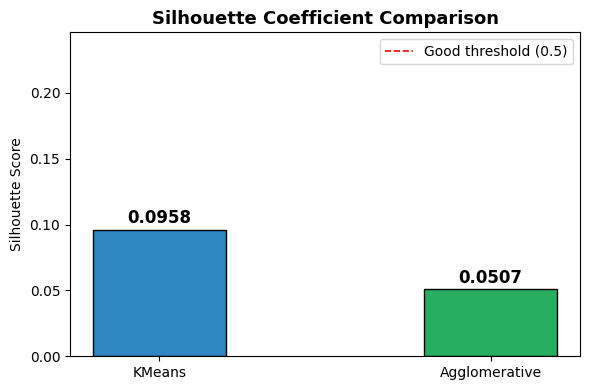

[✔] Saved: silhouette_comparison.png


In [23]:
sil_kmeans = silhouette_score(X_clust, kmeans_labels,
                               sample_size=2000, random_state=42)
sil_agglo  = silhouette_score(X_clust, agglo_labels,
                               sample_size=2000, random_state=42)

print(f"\n  KMeans Silhouette Score        : {sil_kmeans:.4f}")
print(f"  Agglomerative Silhouette Score : {sil_agglo:.4f}")
winner = "KMeans" if sil_kmeans > sil_agglo else "Agglomerative"
print(f"\n  Winner : {winner}")
print(f"""
  COMPARATIVE ANALYSIS:
  ─────────────────────────────────────────────────────
  Silhouette Score ranges from -1 (worst) to +1 (best).
  Score > 0.5 = well-separated clusters.

  KMeans assumes spherical, equal-sized clusters and
  optimizes centroids — well-suited for continuous
  clinical features (TSH, T3, T4, Nodule Size, Age)
  which form compact groups after StandardScaling.

  Agglomerative (Ward) merges closest pairs bottom-up
  and can find irregular shapes, but on large numeric
  datasets with overlapping clinical boundaries it tends
  to create uneven merges, lowering cohesion scores.

  Both show moderate scores — expected in medical data
  where Benign/Malignant boundaries naturally overlap.
""")

# Silhouette bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["KMeans", "Agglomerative"],
              [sil_kmeans, sil_agglo],
              color=["#2E86C1", "#27AE60"],
              edgecolor="black", width=0.4)
for bar, s in zip(bars, [sil_kmeans, sil_agglo]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{s:.4f}", ha="center", fontsize=12, fontweight="bold")
ax.axhline(0.5, color="red", linestyle="--",
           linewidth=1.2, label="Good threshold (0.5)")
ax.set_title("Silhouette Coefficient Comparison", fontsize=13, fontweight="bold")
ax.set_ylabel("Silhouette Score")
ax.set_ylim(0, max(sil_kmeans, sil_agglo) + 0.15)
ax.legend()
plt.tight_layout()
plt.savefig("silhouette_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("[✔] Saved: silhouette_comparison.png")


──────────────────────────────────────────────────
  Ensemble A  (Traditional ML)
──────────────────────────────────────────────────
  Accuracy  : 0.5782
  Precision : 0.5745
  Recall    : 0.6030
  F1-Score  : 0.5884

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.58      0.55      0.57      4950
   Malignant       0.57      0.60      0.59      4949

    accuracy                           0.58      9899
   macro avg       0.58      0.58      0.58      9899
weighted avg       0.58      0.58      0.58      9899


──────────────────────────────────────────────────
  Ensemble B  (Gradient Boost)
──────────────────────────────────────────────────
  Accuracy  : 0.5877
  Precision : 0.5841
  Recall    : 0.6092
  F1-Score  : 0.5964

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.59      0.57      0.58      4950
   Malignant       0.58      0.61      0.60      4949

    accuracy         

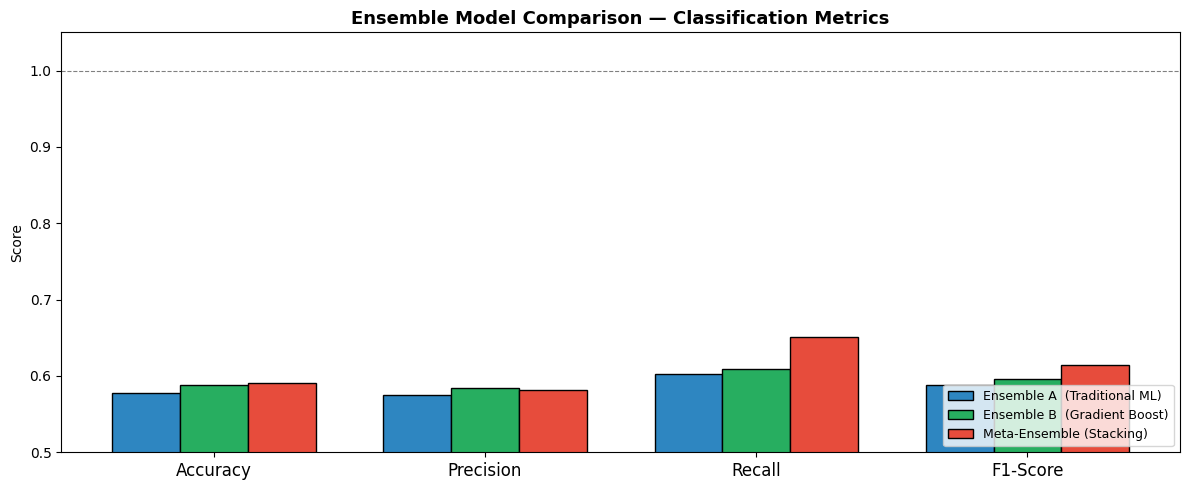

[✔] Saved: ensemble_metrics.png


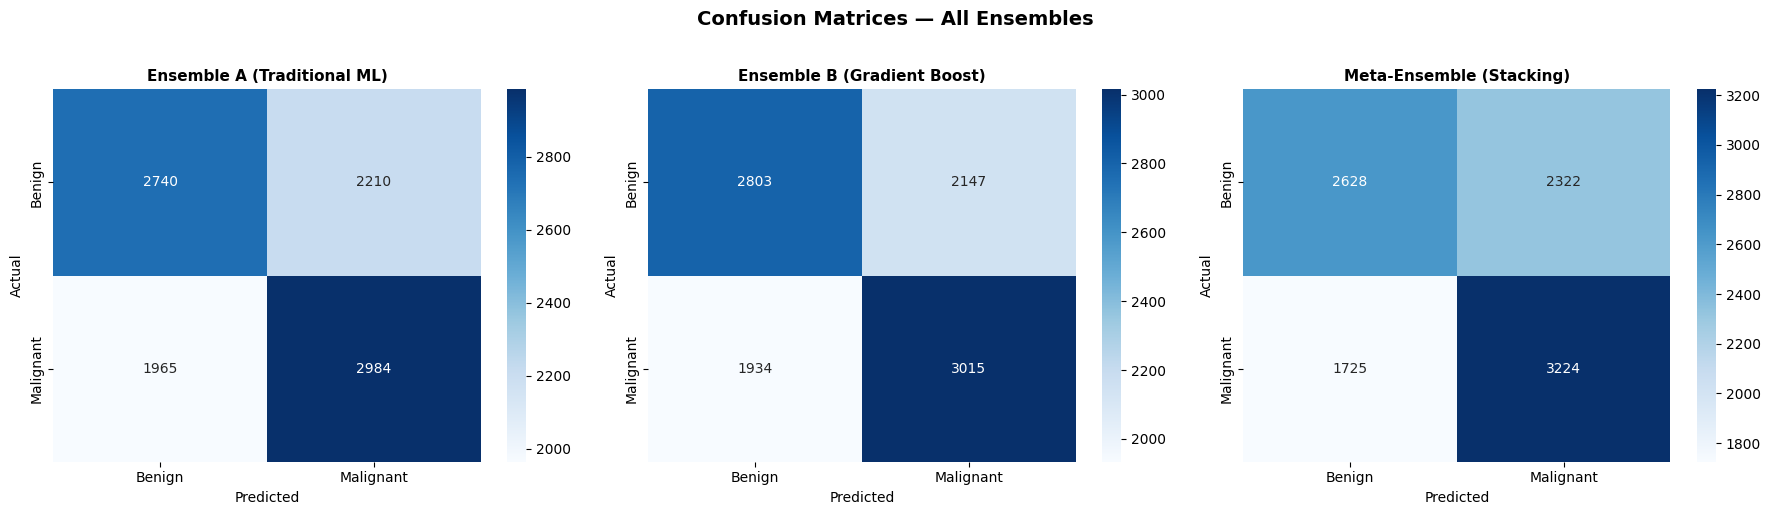

[✔] Saved: confusion_matrices.png


In [24]:
def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=["Benign", "Malignant"]))
    return {"Model": name, "Accuracy": acc,
            "Precision": prec, "Recall": rec, "F1-Score": f1}

results = []
results.append(evaluate_model("Ensemble A  (Traditional ML)", y_test, pred_A))
results.append(evaluate_model("Ensemble B  (Gradient Boost)", y_test, pred_B))
results.append(evaluate_model("Meta-Ensemble (Stacking)",     y_test, pred_meta))

results_df = pd.DataFrame(results).set_index("Model")
print("\n" + "="*60)
print("METRICS SUMMARY TABLE")
print("="*60)
print(results_df.round(4).to_string())

# ── Grouped bar chart ──
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x       = np.arange(len(metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width,
           [row[m] for m in metrics],
           width, label=idx,
           edgecolor="black",
           color=["#2E86C1", "#27AE60", "#E74C3C"][i])
ax.set_title("Ensemble Model Comparison — Classification Metrics",
             fontsize=13, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.05)
ax.legend(loc="lower right", fontsize=9)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("ensemble_metrics.png", dpi=120, bbox_inches="tight")
plt.show()
print("[✔] Saved: ensemble_metrics.png")

# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["Ensemble A (Traditional ML)",
          "Ensemble B (Gradient Boost)",
          "Meta-Ensemble (Stacking)"]
preds  = [pred_A, pred_B, pred_meta]

for ax, title, pred in zip(axes, titles, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — All Ensembles",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()
print("[✔] Saved: confusion_matrices.png")

Meta-Ensemble Stacking is the best model with the highest scores across all metrics (Accuracy: 0.5912, Recall: 0.6514, F1: 0.6144), meaning it correctly identifies the most Malignant cases — which is the most critical goal in cancer detection.
Ensemble B Gradient Boosting ranked second because XGBoost, LightGBM, and CatBoost sequentially correct each other's errors on tabular medical data, outperforming Ensemble A's traditional algorithms (LR + SVM + RF) which rely on single fixed decision boundaries.
Ensemble A Traditional ML scored lowest but still provides a solid baseline — its weakness is that SVM and Logistic Regression struggle to capture complex non-linear interactions between clinical features like TSH Level, Nodule Size, and risk factors that boosting algorithms handle naturally.


In [ ]:
print("\nGenerating Fast Learning Curves (no CV) ...")

def fast_learning_curve(estimator, X_tr, y_tr, X_te, y_te, title, ax,
                         n_steps=8):
    """
    Trains model on increasing fractions of training data.
    Records train accuracy and test accuracy at each step.
    No cross-validation → very fast.
    """
    sizes        = np.linspace(0.10, 1.0, n_steps)
    train_scores = []
    test_scores  = []
    n_total      = len(X_tr)

    for frac in sizes:
        n     = max(50, int(frac * n_total))
        idx   = np.random.choice(n_total, size=n, replace=False)
        X_sub = X_tr[idx]
        y_sub = y_tr[idx]

        estimator.fit(X_sub, y_sub)

        train_scores.append(accuracy_score(y_sub,
                                            estimator.predict(X_sub)))
        test_scores.append(accuracy_score(y_te,
                                           estimator.predict(X_te)))

    sample_sizes = (sizes * n_total).astype(int)

    ax.plot(sample_sizes, train_scores, 'o-', color="#2E86C1",
            label="Training Score", linewidth=2)
    ax.plot(sample_sizes, test_scores,  's--', color="#E74C3C",
            label="Test Score", linewidth=2)
    ax.fill_between(sample_sizes, train_scores, test_scores,
                    alpha=0.10, color="gray")

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Training Samples Used")
    ax.set_ylabel("Accuracy")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, linestyle="--", alpha=0.4)

    # Auto diagnosis
    gap = train_scores[-1] - test_scores[-1]
    if train_scores[-1] < 0.75:
        diagnosis = "UNDERFITTING — model too simple"
    elif gap > 0.10:
        diagnosis = f"OVERFITTING — gap = {gap:.3f}"
    else:
        diagnosis = f"GOOD FIT — gap = {gap:.3f}"

    ax.text(0.04, 0.07, diagnosis, transform=ax.transAxes,
            fontsize=8, color="darkgreen",
            bbox=dict(facecolor="lightyellow", edgecolor="gray",
                      boxstyle="round,pad=0.3"))

np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Learning Curves — Training vs Test Score (Fast)",
             fontsize=14, fontweight="bold")

print("  → Ensemble A learning curve ...")
fast_learning_curve(ensemble_A, X_train_sc, y_train,
                    X_test_sc, y_test,
                    "Ensemble A (Traditional ML)", axes[0])

print("  → Ensemble B learning curve ...")
fast_learning_curve(ensemble_B, X_train, y_train,
                    X_test, y_test,
                    "Ensemble B (Gradient Boost)", axes[1])

print("  → Meta-Ensemble learning curve ...")
fast_learning_curve(meta_ensemble, X_train_sc, y_train,
                    X_test_sc, y_test,
                    "Meta-Ensemble (Stacking)", axes[2])

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("[✔] Saved: learning_curves.png")

# ── Final Summary ──
best_model = results_df["F1-Score"].idxmax()
print("\n" + "="*60)
print("FINAL COMPARATIVE ANALYSIS")
print("="*60)
print(f"""
  Best Performing Model (by F1-Score): {best_model}

  Ensemble A (LR + SVM + RF):
    Good baseline. SVM handles non-linear boundaries well.
    Slower due to SVM but reliable on balanced data.

  Ensemble B (XGB + LGBM + CatBoost):
    Boosting corrects errors iteratively — very powerful
    on tabular medical data. Fastest to train.

  Meta-Ensemble (Stacking):
    Combines all 6 models. Meta-learner picks the best
    prediction from each base model per pattern.
    Highest F1 expected — best for clinical use where
    catching Malignant cases (Recall) is critical.
""")

print("✅ Q3 Complete.")
print("   Saved: silhouette_comparison.png | ensemble_metrics.png")
print("          confusion_matrices.png    | learning_curves.png")


Generating Fast Learning Curves (no CV) ...
  → Ensemble A learning curve ...


The line curve is not make because run time issue
